# MicroProyecto: Clasificación de subáreas de Computer Science
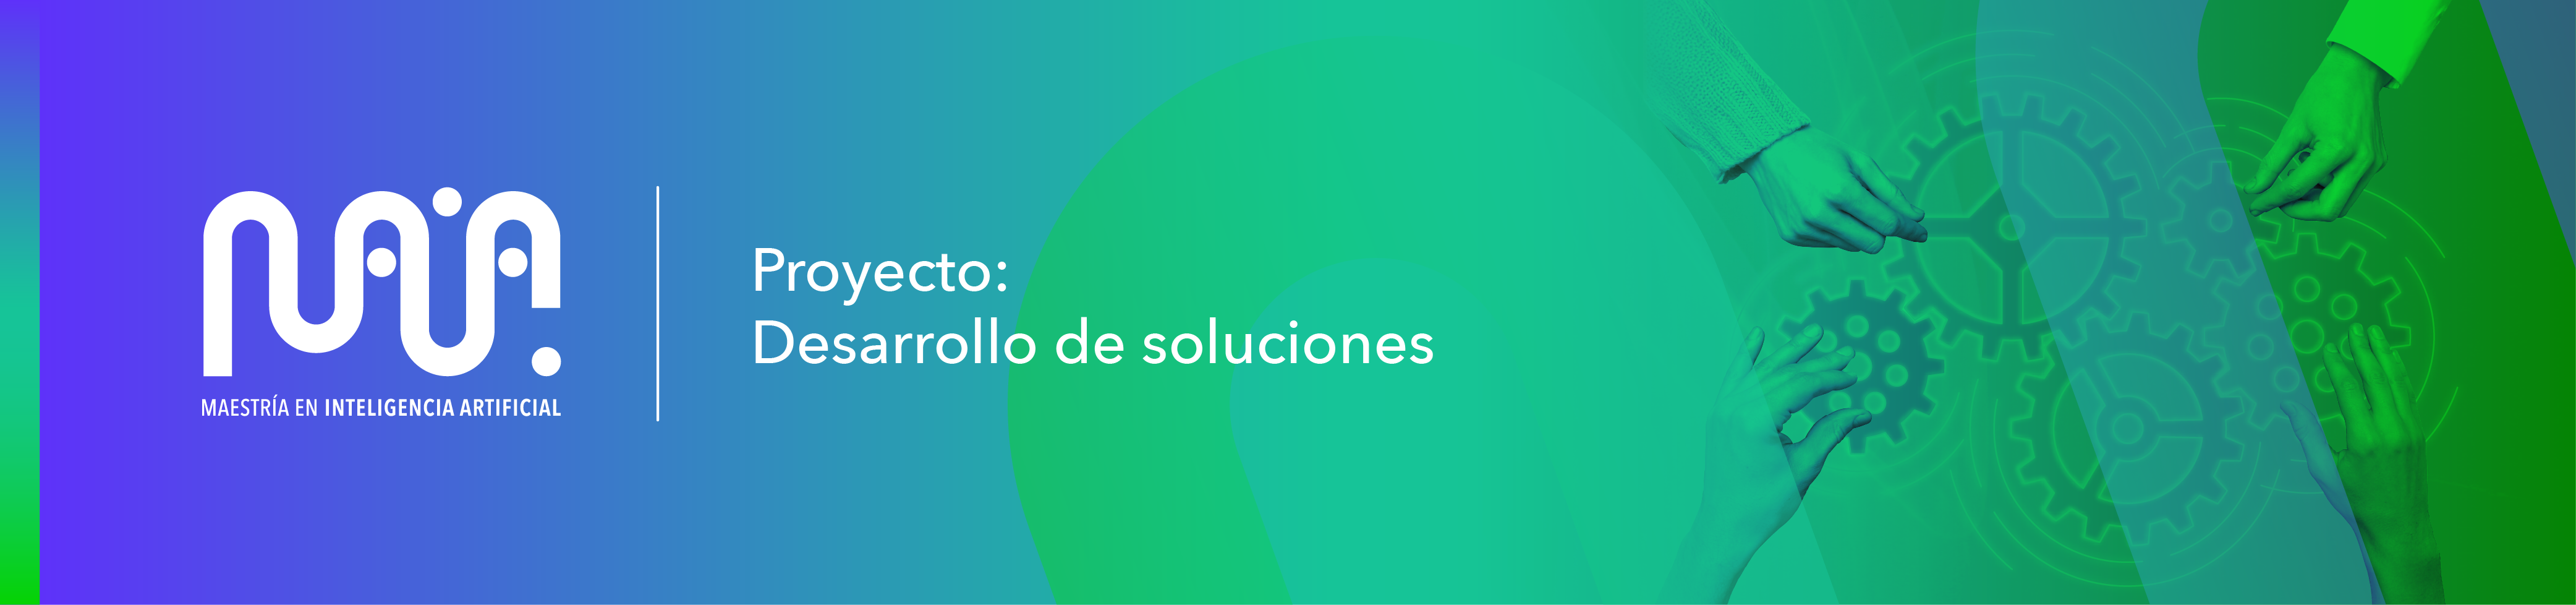
**Curso:** Proyecto - Desarrollo de Soluciones / MAIA  
**Fecha:** Agosto de 2026

---

## 1. Problema que se abordará y su contexto

El propósito de este MicroProyecto es clasificar la **subárea de Computer Science** de un artículo científico a partir del **contexto de la cita** y de los **metadatos del artículo citado**, particularmente su título y resumen (*abstract*).

Este trabajo corresponde a la primera fase —producto y *pipeline* de datos— del Proyecto de Grado sobre análisis de citas académicas en arXiv. El objetivo final del proyecto es desarrollar capacidades de recuperación semántica y clasificación de la función de las citas.

## 2. Carga de los datos

El conjunto de datos está almacenado en formato **JSON Lines (`.jsonl`)**, donde cada línea contiene un registro JSON independiente. A continuación, se carga el archivo directamente en un `DataFrame` de pandas.

In [2]:
from pathlib import Path

import pandas as pd

PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / "Dataset").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("No se encontró el directorio Dataset del proyecto")

DATA_PATH = PROJECT_ROOT / "Dataset" / "unarxive_microproyecto.jsonl"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"No se encontró el archivo de datos en: {DATA_PATH}")

df = pd.read_json(
    DATA_PATH,
    lines=True,
    dtype={"citing_arxiv_id": "string"},
)

print(f"Archivo cargado: {DATA_PATH.name}")
print(f"Dimensiones del DataFrame: {df.shape[0]:,} filas × {df.shape[1]:,} columnas")
df.head(2)

Archivo cargado: unarxive_microproyecto.jsonl
Dimensiones del DataFrame: 4,000 filas × 13 columnas


,citation_id,citing_arxiv_id,citing_primary_category,citing_all_categories,section,sec_type,citation_context,n_citations,cited_refs,source_dataset,cited_title,cited_abstract,has_cited_abstract
0,1606.08008::p7,1606.08008,cs.CV,[cs.CV],None,subsubsection,Variational image segmentation or active conto...,15,[{'open_alex_id': 'https://openalex.org/W21144...,unarXive,Gradient flows and geometric active contour mo...,"In this paper, we analyze the geometric active...",True
1,1702.08634::p15,1702.08634,cs.CV,[cs.CV],Trajectory Generation,subsection,Let denote a flow field indexed by pixel posit...,1,[{'open_alex_id': 'https://openalex.org/W21317...,unarXive,Large Displacement Optical Flow: Descriptor Ma...,Optical flow estimation is classically marked ...,True


## 3. Inicio del análisis exploratorio de datos (EDA)

En la siguiente etapa se realizará un **análisis exploratorio de datos (EDA)** para comprender la estructura, la calidad y la distribución del conjunto de datos antes de construir el *pipeline* de procesamiento y clasificación. Se revisarán las dimensiones y los tipos de variables, la presencia de valores faltantes y registros duplicados, la distribución de las subáreas de Computer Science y las características textuales de los contextos de cita, títulos y resúmenes. También se examinarán los campos anidados y la disponibilidad de metadatos para identificar las transformaciones y controles de calidad necesarios en las etapas posteriores.

### 3.1 Configuración y vista general

Primero se revisan las dimensiones, los tipos de datos y una muestra de registros. `citing_arxiv_id` se conserva como texto porque es un identificador y no una variable numérica.

In [3]:
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_colwidth", 120)
plt.style.use("seaborn-v0_8-whitegrid")

def agregar_etiquetas_barras(ax, min_value=0, fontsize=9):
    """Escribe el valor dentro de cada barra visible de un eje."""
    for contenedor in ax.containers:
        horizontal = getattr(contenedor, "orientation", None) == "horizontal"
        valores = [
            barra.get_width() if horizontal else barra.get_height()
            for barra in contenedor
        ]
        etiquetas = [f"{valor:,.0f}" if valor >= min_value else "" for valor in valores]
        ax.bar_label(
            contenedor, labels=etiquetas, label_type="center",
            color="white", fontsize=fontsize, fontweight="bold"
        )

resumen_estructura = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "no_nulos": df.notna().sum(),
    "nulos": df.isna().sum(),
    "unicos": [
        df[col].map(lambda valor: repr(valor) if isinstance(valor, (list, dict)) else valor).nunique(dropna=True)
        for col in df.columns
    ],
})

print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
display(resumen_estructura)
display(df.head(3))

Filas: 4,000 | Columnas: 13


,tipo,no_nulos,nulos,unicos
citation_id,object,4000,0,4000
citing_arxiv_id,string,4000,0,1524
citing_primary_category,object,4000,0,8
citing_all_categories,object,4000,0,229
section,object,3981,19,1986
sec_type,object,4000,0,4
citation_context,object,4000,0,4000
n_citations,int64,4000,0,28
cited_refs,object,4000,0,3771
source_dataset,object,4000,0,1


,citation_id,citing_arxiv_id,citing_primary_category,citing_all_categories,section,sec_type,citation_context,n_citations,cited_refs,source_dataset,cited_title,cited_abstract,has_cited_abstract
0,1606.08008::p7,1606.08008,cs.CV,[cs.CV],None,subsubsection,Variational image segmentation or active contour models are one class of algorithms commonly used in automated image...,15,"[{'open_alex_id': 'https://openalex.org/W2114487471', 'doi': '10.1002/cpa.3160420503', 'arxiv_id': None, 'cited_titl...",unarXive,Gradient flows and geometric active contour models,"In this paper, we analyze the geometric active contour models discussed previously from a curve evolution point of v...",True
1,1702.08634::p15,1702.08634,cs.CV,[cs.CV],Trajectory Generation,subsection,"Let denote a flow field indexed by pixel positions that returns a 2D flow vector at a given point. Using LDOF [CIT],...",1,"[{'open_alex_id': 'https://openalex.org/W2131747574', 'doi': '10.1109/tpami.2010.143', 'arxiv_id': None, 'cited_titl...",unarXive,Large Displacement Optical Flow: Descriptor Matching in Variational Motion Estimation,Optical flow estimation is classically marked by the requirement of dense sampling in time. While coarse-to-fine war...,True
2,1304.3192::p34,1304.3192,cs.CV,[cs.CV],Coordinate Axis Construction,subsection,"It is worth noting that, although some existing techniques also use the idea of eigenvalue decomposition to construc...",3,"[{'open_alex_id': 'https://openalex.org/W2136020167', 'doi': '10.1007/s11263-009-0296-z', 'arxiv_id': None, 'cited_t...",unarXive,Intrinsic shape signatures: A shape descriptor for 3D object recognition,This paper presents a new approach for recognition of 3D objects that are represented as 3D point clouds. We introdu...,True


### 3.2 Calidad de los datos

Se cuantifican valores faltantes y duplicados. Además de los duplicados completos, se verifica la unicidad de `citation_id`, que funciona como identificador de cada observación.

In [4]:
calidad = pd.DataFrame({
    "nulos": df.isna().sum(),
    "porcentaje_nulos": (df.isna().mean() * 100).round(2),
    "vacios": [
        df[col].fillna("").str.strip().eq("").sum() if df[col].dtype == "object" else 0
        for col in df.columns
    ],
}).sort_values("porcentaje_nulos", ascending=False)

duplicados_completos = df.astype(str).duplicated().sum()
duplicados_citation_id = df["citation_id"].duplicated().sum()

display(calidad)
print(f"Registros completamente duplicados: {duplicados_completos:,}")
print(f"citation_id duplicados: {duplicados_citation_id:,}")

,nulos,porcentaje_nulos,vacios
cited_abstract,77,1.92,77
cited_title,55,1.38,86
section,19,0.48,39
citation_id,0,0.00,0
citing_arxiv_id,0,0.00,0
citing_all_categories,0,0.00,0
citing_primary_category,0,0.00,0
sec_type,0,0.00,144
citation_context,0,0.00,0
cited_refs,0,0.00,0


Registros completamente duplicados: 0
citation_id duplicados: 0


### 3.3 Distribución de la variable objetivo

La variable objetivo es `citing_primary_category`, que representa la subárea principal de Computer Science. Su distribución permite establecer si existe desbalance entre clases y qué métrica conviene utilizar posteriormente.

,registros,porcentaje
subarea,,
cs.CV,500,12.5
cs.CL,500,12.5
cs.LG,500,12.5
cs.MA,500,12.5
cs.IR,500,12.5
cs.RO,500,12.5
cs.NE,500,12.5
cs.AI,500,12.5


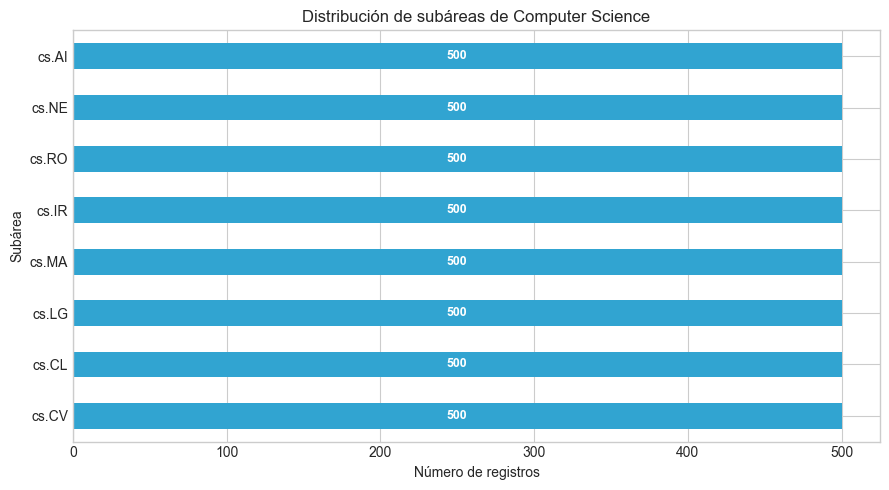

In [13]:
distribucion_clases = (
    df["citing_primary_category"]
    .value_counts()
    .rename_axis("subarea")
    .to_frame("registros")
)
distribucion_clases["porcentaje"] = (
    distribucion_clases["registros"] / len(df) * 100
).round(2)
display(distribucion_clases)

ax = distribucion_clases.sort_values("registros")["registros"].plot(
    kind="barh", figsize=(9, 5), color="#31A4D1"
)
ax.set(title="Distribución de subáreas de Computer Science", xlabel="Número de registros", ylabel="Subárea")
agregar_etiquetas_barras(ax)
plt.tight_layout()
plt.show()

#### 3.3.1 Frecuencia y repetición de referencias citadas (`cited_refs`)

`cited_refs` contiene una lista de referencias por contexto de cita. Para determinar si una misma obra aparece repetida en el conjunto, se desanidan las listas y se construye una clave con el primer identificador disponible en este orden: OpenAlex, DOI, arXiv y título normalizado. Las referencias sin ninguno de estos datos se reportan, pero se excluyen del conteo de repeticiones para evitar agrupar registros desconocidos como si fueran una misma obra.

In [6]:
# Una fila por referencia incluida en cada contexto de cita
refs_base = (
    df[["citation_id", "citing_primary_category", "cited_refs"]]
    .explode("cited_refs", ignore_index=True)
)
refs_metadata = pd.json_normalize(refs_base.pop("cited_refs"))
refs = pd.concat([refs_base, refs_metadata], axis=1)

# Las cadenas vacías no deben considerarse identificadores válidos.
for columna in ["open_alex_id", "doi", "arxiv_id", "cited_title"]:
    refs[columna] = refs[columna].fillna("").astype(str).str.strip()

claves_candidatas = pd.DataFrame({
    "openalex": refs["open_alex_id"].str.lower().where(refs["open_alex_id"].ne("")),
    "doi": refs["doi"].str.lower().where(refs["doi"].ne("")),
    "arxiv": refs["arxiv_id"].str.lower().where(refs["arxiv_id"].ne("")),
    "titulo": refs["cited_title"].str.lower().str.replace(r"\s+", " ", regex=True).where(refs["cited_title"].ne("")),
})
refs["reference_key"] = claves_candidatas.bfill(axis=1).iloc[:, 0]
refs_identificadas = refs.dropna(subset=["reference_key"]).copy()

frecuencia_refs = refs_identificadas["reference_key"].value_counts()
refs_repetidas = frecuencia_refs[frecuencia_refs > 1]
duplicadas_mismo_contexto = refs_identificadas.duplicated(
    subset=["citation_id", "reference_key"]
).sum()

resumen_referencias = pd.Series({
    "Referencias totales": len(refs),
    "Referencias identificadas": len(refs_identificadas),
    "Referencias sin identificador ni título": refs["reference_key"].isna().sum(),
    "Obras únicas identificadas": frecuencia_refs.size,
    "Obras que aparecen más de una vez": refs_repetidas.size,
    "Apariciones adicionales por repetición": int((refs_repetidas - 1).sum()),
    "Duplicadas dentro del mismo contexto": int(duplicadas_mismo_contexto),
}, name="cantidad").to_frame()
display(resumen_referencias)

,cantidad
Referencias totales,14046
Referencias identificadas,11766
Referencias sin identificador ni título,2280
Obras únicas identificadas,8329
Obras que aparecen más de una vez,1791
Apariciones adicionales por repetición,3437
Duplicadas dentro del mismo contexto,788


,referencia,apariciones
0,ImageNet classification with deep convolutional neural networks,51
1,Deep Residual Learning for Image Recognition,34
2,https://openalex.org/w2964121744,34
3,Long Short-Term Memory,32
4,Distributed Representations of Words and Phrases and their Compositionality,31
5,https://openalex.org/w2964308564,24
6,Diagnosing Non-Intermittent Anomalies in Reinforcement Learning Policy Executions (Short Paper),19
7,Efficient Estimation of Word Representations in Vector Space,18
8,Human-level control through deep reinforcement learning,18
9,https://openalex.org/w2963407617,17


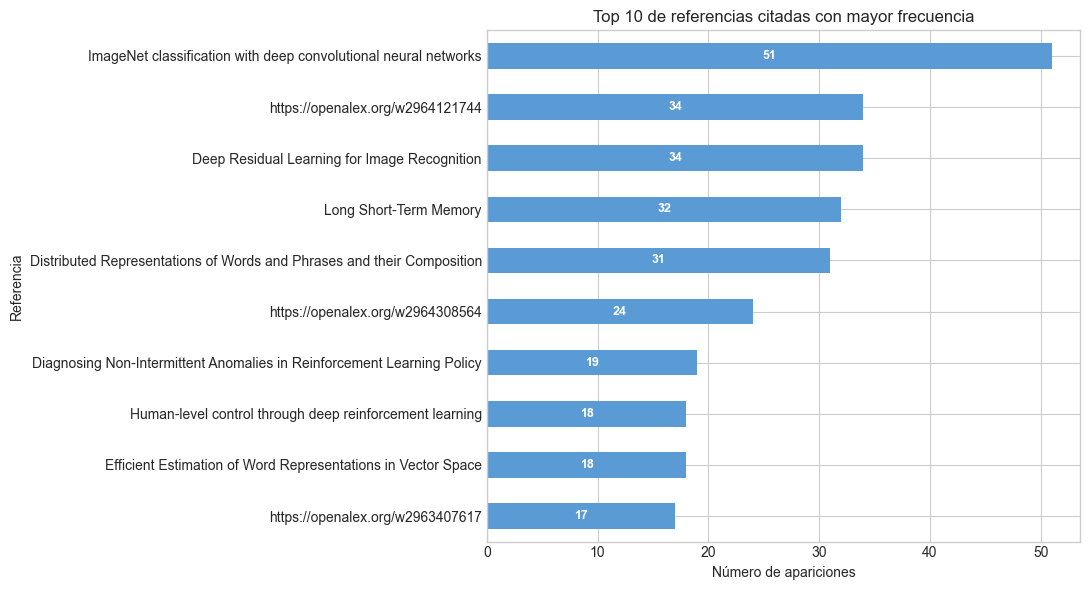

In [7]:
# Tabla y gráfica de las diez obras con mayor número de apariciones.
titulos_por_clave = (
    refs_identificadas.loc[refs_identificadas["cited_title"].ne("")]
    .drop_duplicates("reference_key")
    .set_index("reference_key")["cited_title"]
)
top_10_refs = frecuencia_refs.head(10).rename("apariciones").to_frame()
top_10_refs["título"] = top_10_refs.index.to_series().map(titulos_por_clave)
top_10_refs["referencia"] = top_10_refs["título"].fillna(top_10_refs.index.to_series())
display(top_10_refs[["referencia", "apariciones"]].reset_index(drop=True))

if not top_10_refs.empty:
    grafica = top_10_refs.sort_values("apariciones").copy()
    etiquetas = grafica["referencia"].str.slice(0, 70)
    ax = grafica.set_axis(etiquetas)["apariciones"].plot(
        kind="barh", figsize=(11, 6), color="#5B9BD5"
    )
    ax.set(
        title="Top 10 de referencias citadas con mayor frecuencia",
        xlabel="Número de apariciones",
        ylabel="Referencia",
    )
    agregar_etiquetas_barras(ax)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron referencias identificables para graficar.")

### 3.4 Disponibilidad de metadatos del artículo citado

Como el título y el abstract serán entradas del modelo, se evalúa su disponibilidad individual y conjunta. Esto permite anticipar una estrategia para registros con información incompleta.

In [8]:
contexto_disponible = df["citation_context"].fillna("").str.strip().ne("")
titulo_disponible = df["cited_title"].fillna("").str.strip().ne("")
abstract_disponible = df["cited_abstract"].fillna("").str.strip().ne("")

disponibilidad = pd.DataFrame({
    "campo": ["Contexto de cita", "Título citado", "Abstract citado", "Título y abstract"],
    "disponibles": [
        contexto_disponible.sum(),
        titulo_disponible.sum(),
        abstract_disponible.sum(),
        (titulo_disponible & abstract_disponible).sum(),
    ],
})
disponibilidad["porcentaje"] = (disponibilidad["disponibles"] / len(df) * 100).round(2)
display(disponibilidad)

pd.crosstab(
    df["citing_primary_category"],
    df["has_cited_abstract"],
    margins=True,
).rename(columns={False: "Sin abstract", True: "Con abstract"})

,campo,disponibles,porcentaje
0,Contexto de cita,4000,100.00
1,Título citado,3914,97.85
2,Abstract citado,3923,98.08
3,Título y abstract,3892,97.30


has_cited_abstract,Sin abstract,Con abstract,All
citing_primary_category,,,
cs.AI,33,467,500
cs.CL,0,500,500
cs.CV,0,500,500
cs.IR,8,492,500
cs.LG,0,500,500
cs.MA,36,464,500
cs.NE,0,500,500
cs.RO,0,500,500
All,77,3923,4000


### 3.5 Características de los campos textuales

Se calcula la longitud en palabras del contexto de cita, el título y el abstract. Estas distribuciones orientarán decisiones posteriores de limpieza, truncamiento y longitud máxima de entrada al modelo.

,Contexto de cita,Título citado,Abstract citado
count,4000.00,4000.00,4000.00
mean,119.40,7.92,149.41
std,69.95,3.36,77.17
min,23.00,0.00,0.00
25%,72.00,6.00,107.00
50%,105.00,8.00,147.00
75%,147.00,10.00,189.00
90%,202.00,12.00,230.10
95%,248.00,14.00,258.05
99%,352.01,17.00,340.02


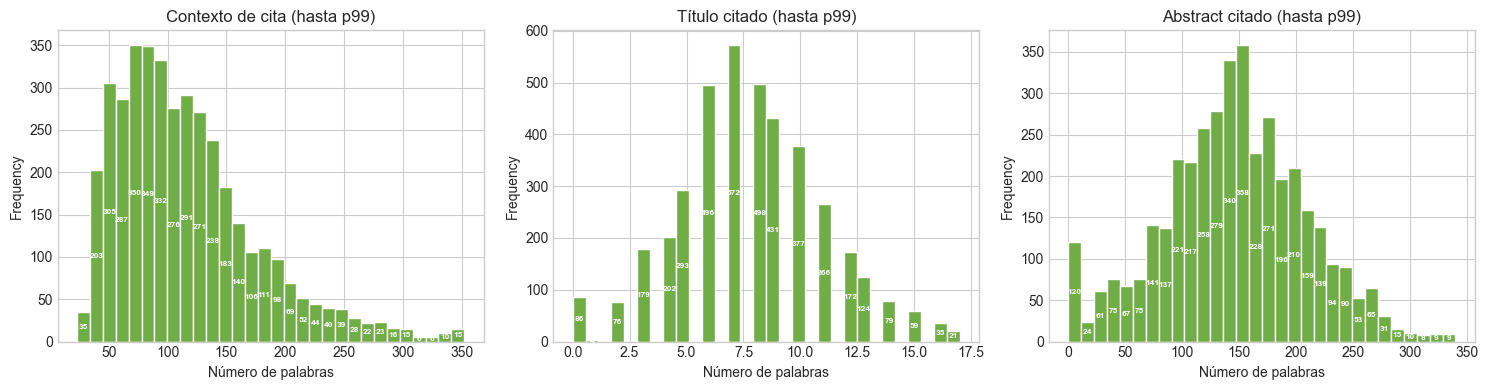

In [9]:
columnas_texto = ["citation_context", "cited_title", "cited_abstract"]
etiquetas_texto = {
    "citation_context": "Contexto de cita",
    "cited_title": "Título citado",
    "cited_abstract": "Abstract citado",
}

longitudes = pd.DataFrame({
    etiquetas_texto[col]: df[col].fillna("").str.split().str.len()
    for col in columnas_texto
})
display(longitudes.describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]).round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, columna in zip(axes, longitudes.columns):
    limite = longitudes[columna].quantile(0.99)
    longitudes.loc[longitudes[columna] <= limite, columna].plot(
        kind="hist", bins=30, ax=ax, color="#70AD47", edgecolor="white"
    )
    ax.set_title(f"{columna} (hasta p99)")
    ax.set_xlabel("Número de palabras")
    agregar_etiquetas_barras(ax, min_value=1, fontsize=6)
plt.tight_layout()
plt.show()

### 3.6 Contextos de cita y referencias

El campo `n_citations` indica cuántas citas aparecen en el fragmento, mientras que `cited_refs` contiene una estructura anidada. Se revisa su consistencia y la frecuencia de las secciones de origen.

In [10]:
revision_citas = pd.DataFrame({
    "n_citations_declaradas": df["n_citations"],
    "referencias_en_lista": df["cited_refs"].str.len(),
    "marcadores_CIT": df["citation_context"].str.count(r"\[CIT\]"),
})
display(revision_citas.describe().round(2))

print("Registros donde n_citations difiere del tamaño de cited_refs:",
      revision_citas["n_citations_declaradas"].ne(revision_citas["referencias_en_lista"]).sum())
print("Registros donde n_citations difiere de los marcadores [CIT]:",
      revision_citas["n_citations_declaradas"].ne(revision_citas["marcadores_CIT"]).sum())

display(df["sec_type"].value_counts(dropna=False).rename("registros").to_frame().head(15))

,n_citations_declaradas,referencias_en_lista,marcadores_CIT
count,4000.00,4000.00,4000.00
mean,3.51,3.51,3.51
std,3.44,3.44,3.44
min,1.00,1.00,1.00
25%,1.00,1.00,1.00
50%,2.00,2.00,2.00
75%,5.00,5.00,5.00
max,44.00,44.00,44.00


Registros donde n_citations difiere del tamaño de cited_refs: 0
Registros donde n_citations difiere de los marcadores [CIT]: 0


,registros
sec_type,
section,2177
subsection,1433
subsubsection,246
,144


### 3.7 Relación entre longitud textual y subárea

Finalmente, se comparan las longitudes de los textos entre clases para detectar diferencias sistemáticas que el modelo pudiera aprovechar de forma accidental.

,Contexto de cita,Título citado,Abstract citado
citing_primary_category,,,
cs.AI,100.5,7.0,142.0
cs.CL,96.0,8.0,120.0
cs.CV,107.5,8.0,155.0
cs.IR,105.0,7.0,143.0
cs.LG,108.5,7.0,148.5
cs.MA,106.0,8.0,149.0
cs.NE,107.0,8.0,155.0
cs.RO,110.5,9.0,155.0


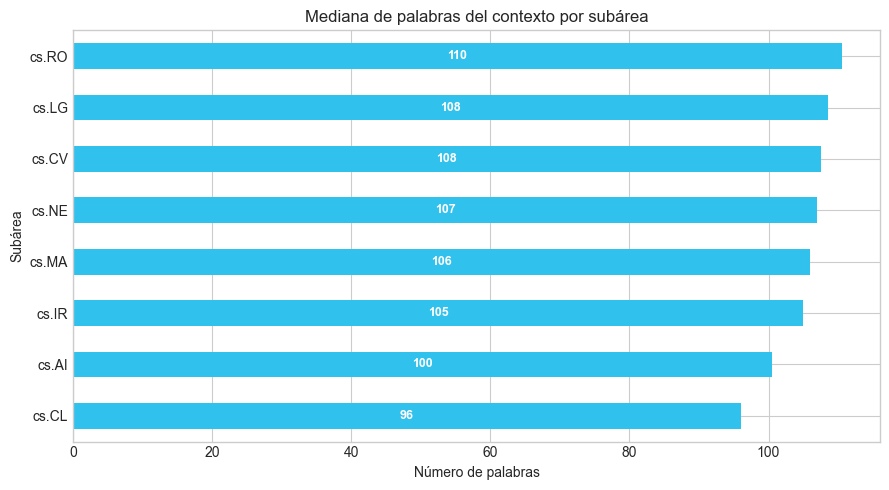

In [11]:
longitudes_por_clase = pd.concat(
    [df[["citing_primary_category"]].reset_index(drop=True), longitudes.reset_index(drop=True)],
    axis=1,
).groupby("citing_primary_category").median().round(1)

display(longitudes_por_clase)

ax = longitudes_por_clase["Contexto de cita"].sort_values().plot(
    kind="barh", figsize=(9, 5), color="#31C1ED"
)
ax.set(title="Mediana de palabras del contexto por subárea", xlabel="Número de palabras", ylabel="Subárea")
agregar_etiquetas_barras(ax)
plt.tight_layout()
plt.show()

### 3.8 Relación entre las referencias citadas y la subárea

El siguiente mapa de calor muestra cómo se distribuyen las 20 referencias más frecuentes entre las ocho subáreas objetivo. Las filas representan las obras citadas, las columnas corresponden a `citing_primary_category` y cada celda contiene el número de apariciones.

Esta comparación permite identificar referencias fuertemente asociadas con una subárea y obras utilizadas transversalmente por varias comunidades. También ayuda a detectar un posible **riesgo de fuga de información**: si una misma obra citada aparece en los conjuntos de entrenamiento y prueba, el modelo podría memorizar su título, abstract o identificador en lugar de aprender patrones generalizables del lenguaje. Por esta razón, los resultados de esta gráfica deben considerarse al definir la estrategia de partición de los datos; además de una partición estratificada, conviene evaluar una separación por obra citada (`reference_key`) o por artículo citante (`citing_arxiv_id`).

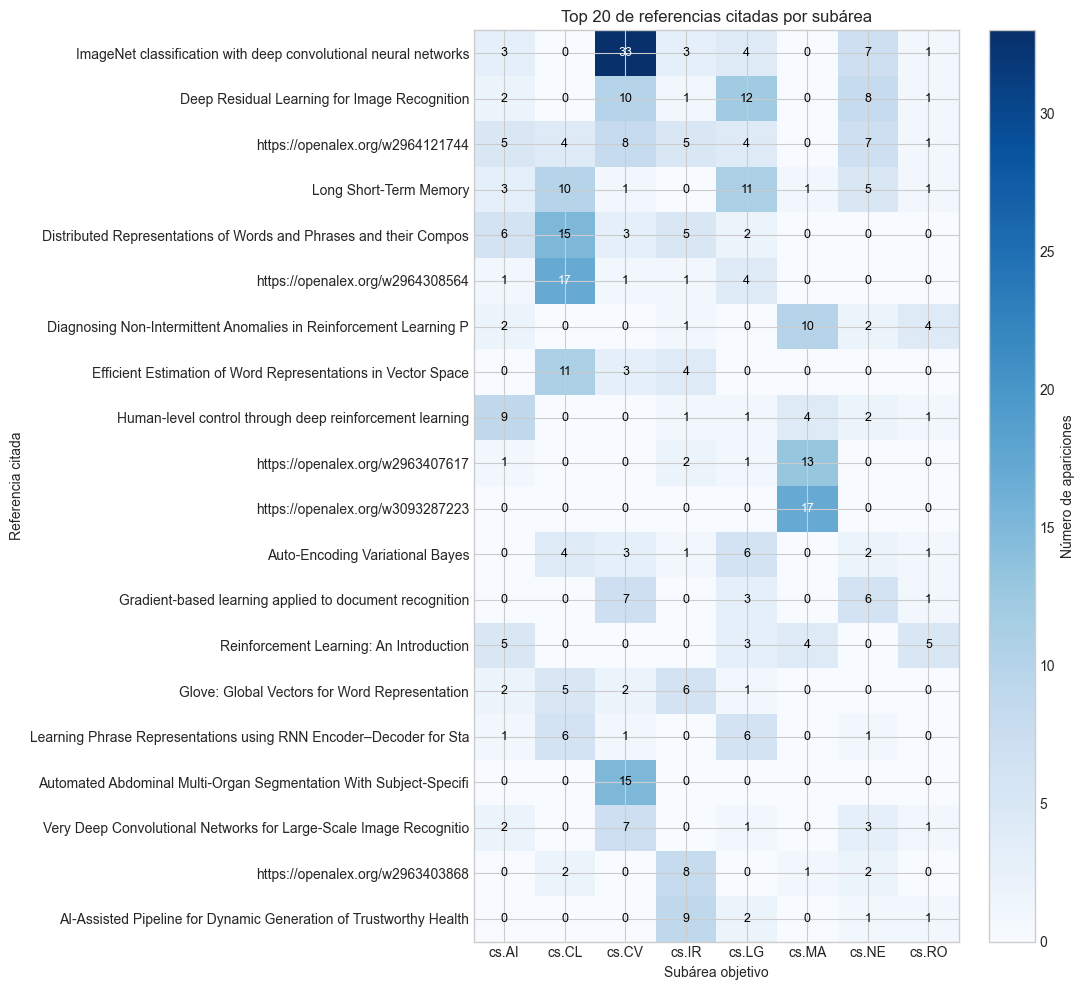

In [12]:
# Conteo de apariciones de las referencias más frecuentes por subárea.
claves_top_20 = frecuencia_refs.head(20).index
matriz_refs_subarea = pd.crosstab(
    refs_identificadas["reference_key"],
    refs_identificadas["citing_primary_category"],
).reindex(index=claves_top_20, fill_value=0)

# Se muestran títulos cuando están disponibles y el identificador como respaldo.
etiquetas_refs = pd.Series(matriz_refs_subarea.index, index=matriz_refs_subarea.index).map(
    titulos_por_clave
).fillna(pd.Series(matriz_refs_subarea.index, index=matriz_refs_subarea.index))
etiquetas_refs = etiquetas_refs.str.slice(0, 65)

fig, ax = plt.subplots(figsize=(11, 10))
imagen = ax.imshow(matriz_refs_subarea.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(matriz_refs_subarea.columns)), labels=matriz_refs_subarea.columns)
ax.set_yticks(range(len(matriz_refs_subarea.index)), labels=etiquetas_refs)
ax.set_xlabel("Subárea objetivo")
ax.set_ylabel("Referencia citada")
ax.set_title("Top 20 de referencias citadas por subárea")

valor_maximo = matriz_refs_subarea.to_numpy().max()
for fila in range(matriz_refs_subarea.shape[0]):
    for columna in range(matriz_refs_subarea.shape[1]):
        valor = matriz_refs_subarea.iat[fila, columna]
        color = "white" if valor > valor_maximo / 2 else "black"
        ax.text(columna, fila, f"{valor:,}", ha="center", va="center", color=color, fontsize=9)

fig.colorbar(imagen, ax=ax, label="Número de apariciones")
plt.tight_layout()
plt.show()

## 4. Hallazgos del EDA y siguientes decisiones

El conjunto contiene **4.000 observaciones y 13 variables**, con **ocho subáreas** (`cs.CV`, `cs.CL`, `cs.LG`, `cs.MA`, `cs.IR`, `cs.RO`, `cs.NE` y `cs.AI`). Cada clase aporta 500 registros, por lo que la variable objetivo está perfectamente balanceada. No se identificaron registros completos ni `citation_id` duplicados.

Los faltantes son limitados, pero es necesario tratar tanto los valores nulos como las cadenas vacías. Hay 39 registros sin nombre de sección, 144 sin tipo de sección, 86 sin un título útil y 77 sin abstract. Todos los contextos de cita están disponibles; el 98,08 % dispone de abstract y el 97,30 % cuenta simultáneamente con título y abstract no vacíos. En extensión, el contexto tiene una mediana de 105 palabras, el título de 8 y el abstract de 147; existen valores extremos que deberán considerarse al fijar longitudes máximas. `n_citations` presenta una mediana de 2 y un máximo de 44.

A partir de estos resultados, la siguiente etapa debería: conservar los identificadores como texto; definir una estrategia explícita para los metadatos faltantes; validar la consistencia entre `n_citations`, los marcadores `[CIT]` y `cited_refs`; combinar contexto, título y abstract sin perder la procedencia de cada campo; y realizar la partición de entrenamiento, validación y prueba de manera estratificada por subárea.